In [1]:
from sklearn.model_selection import train_test_split
import os
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image
import parselmouth
import pandas as pd
from tensorflow.keras.models import load_model
from sincnet_tensorflow import LayerNorm 
from sklearn.metrics import f1_score
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, LeakyReLU, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
import librosa.display
import soundfile as sf  
import librosa

Generador de imágenes a partir de los audios y guardarlas en local 

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os

# Ruta de entrada y salida
input_folder = 'not_padded'  # Carpeta con los archivos .wav
output_folder = 'mel_spectrograms_vggish'  # Carpeta para guardar las imágenes
os.makedirs(output_folder, exist_ok=True)

# Parámetros para el espectrograma
target_sr = 16000  # Frecuencia de muestreo
n_mels = 64
n_fft = 400
hop_length = 160

# Procesar los archivos de audio
for file_name in os.listdir(input_folder):
    if file_name.endswith('.wav'):  # Procesar solo archivos .wav
        file_path = os.path.join(input_folder, file_name)
        try:
            # Cargar el archivo de audio
            y, sr = librosa.load(file_path, sr=target_sr)

            # Crear el espectrograma de Mel
            mel_spectrogram = librosa.feature.melspectrogram(
                y=y,
                sr=sr,
                n_fft=n_fft,
                hop_length=hop_length,
                n_mels=n_mels,
                fmin=125,
                fmax=7500
            )

            # Convertir a escala logarítmica
            log_mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)

            # Asegurar que tenga 96 frames temporales
            if log_mel_spectrogram.shape[1] < 96:
                pad_width = 96 - log_mel_spectrogram.shape[1]
                log_mel_spectrogram = np.pad(log_mel_spectrogram, ((0, 0), (0, pad_width)), mode='constant')
            else:
                log_mel_spectrogram = log_mel_spectrogram[:, :96]

            # Crear una figura sin ejes ni colorbar
            plt.figure(figsize=(2.56, 1.71))  # Tamaño inicial aproximado en pulgadas
            plt.axis('off')  # Ocultar los ejes
            librosa.display.specshow(log_mel_spectrogram, sr=sr, hop_length=hop_length, fmin=125, fmax=7500, cmap='viridis')

            # Guardar la imagen temporalmente
            temp_output_path = os.path.join(output_folder, f"temp_{os.path.splitext(file_name)[0]}.png")
            plt.savefig(temp_output_path, dpi=96, bbox_inches='tight', pad_inches=0)
            plt.close()

            # Cargar la imagen temporal y redimensionar a 96x64
            img = Image.open(temp_output_path)
            img_resized = img.resize((96, 64), Image.ANTIALIAS)

            img_array = np.array(img_resized)

            if img_array.shape[-1] == 4:  # Si la imagen tiene 4 canales (viridis incluye una dimension alfa)
                img_array = img_array[:, :, :3]  # Mantener solo los tres primeros canales (RGB)

            # Convertir nuevamente a imagen PIL
            img_resized_rgb = Image.fromarray(img_array)

            # Guardar la imagen final
            final_output_path = os.path.join(output_folder, f"{os.path.splitext(file_name)[0]}.png")
            img_resized_rgb.save(final_output_path)

            # Eliminar la imagen temporal
            os.remove(temp_output_path)

        except Exception as e:
            print(f"Error procesando {file_name}: {e}")


Comprobar que el formato sea 96x64 píxeles, que es la entrada que pide VGGISH para crear los embeddings.

Tamaño de la imagen: (64, 96, 3)


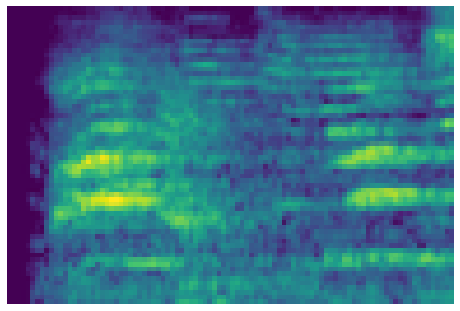

In [20]:
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
# Cargar la imagen con PIL (como en tu código original)

img = Image.open('c:/Users/mussi/Desktop/TFG/mel_spectrograms_vggish/1audio_22.png')

# Convertir la imagen a un array numpy
img_array = np.array(img)

# Ver las dimensiones de la imagen
print(f'Tamaño de la imagen: {img_array.shape}')

# Plotear la imagen
plt.figure(figsize=(8, 8))
plt.imshow(img_array)
plt.axis('off')  # Ocultar los ejes
plt.show()


Generar la variable 'X' con las imágenes guardadas en local

In [2]:
# Ruta a la carpeta de imágenes
image_folder = 'mel_spectrograms_vggish'
# Lista para almacenar las imágenes cargadas
X = []

# Recorrer las posibles combinaciones de x y y
for x in range(1, 26):  # X va de 1 a 25
    for y in range(2, 77):  # Y va de 2 a 76
        # Crear el nombre del archivo con el formato 'xaudio_y_completo.png'
        image_name = f'{x}audio_{y}.png'
        image_path = os.path.join(image_folder, image_name)

        # Comprobar si el archivo existe
        if os.path.isfile(image_path):
            try:
                # Cargar la imagen generada del espectrograma
                img = Image.open(image_path)


                # Convertir la imagen a una matriz numpy
                img_array_resized = np.array(img)

                # Agregar la imagen a la lista
                X.append(img_array_resized)

            except Exception as e:
                print(f"Error al procesar la imagen {image_name}: {e}")

# Convertir la lista en un array numpy
X = np.array(X)

# Verificar la forma final de las imágenes cargadas
print(f"Imágenes cargadas en la variable X con forma: {X.shape}")



Imágenes cargadas en la variable X con forma: (1870, 64, 96, 3)


Visualizar un valor de X

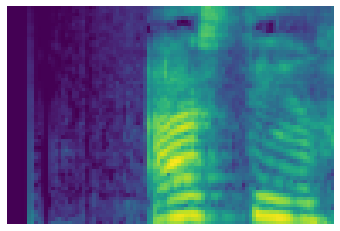

In [34]:
# Asegurarse de que hay imágenes en X
if len(X) > 0:
    # Tomar la primera imagen
    image = X[1660]

    # Quitar la dimensión extra para mostrar la imagen en escala de grises
    plt.imshow(image.squeeze(), cmap='gray')

    # Título y ajustes del gráfico
    plt.axis('off')  # Ocultar los ejes

    # Mostrar la imagen
    plt.show()
else:
    print("La variable X está vacía.")


Generar variable 'y' a partir del etiquetamiento de datos en el csv.

In [3]:
# Cargar el archivo CSV
data = pd.read_csv('data.csv')

# Seleccionar las columnas desde la segunda hasta la décima
y = data.iloc[:, 1:10]  # La segunda columna tiene índice 1, y la décima tiene índice 9 (excluyendo la décima primera)

# Verificar el resultado
print(f"Forma de la variable y: {y.shape}")
print(y.head())  # Mostrar las primeras filas de y


Forma de la variable y: (1870, 9)
   1  2  3  4  5  6  7  8  9
0  0  0  0  1  0  0  0  0  0
1  0  1  0  1  0  0  0  0  0
2  0  0  0  1  0  0  0  0  0
3  0  0  1  1  0  0  0  0  0
4  1  0  1  1  0  0  0  1  0


Generar datos de train y validación

In [4]:
# Divide los datos en entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((1496, 64, 96, 3), (374, 64, 96, 3), (1496, 9), (374, 9))

Arquitectura de modelo con Conv2D

In [6]:
out_dim = 9  # número de clases

# Definir las entradas con forma (150, 150, 1)
inputs = Input((64, 96, 3))

# Primera capa Conv2D
x = Conv2D(32, (3, 3), strides=1, padding='same')(inputs)
x = LeakyReLU(alpha=0.2)(x)
x = MaxPooling2D(pool_size=(2, 2))(x)

# Segunda capa Conv2D
x = Conv2D(64, (3, 3), strides=1, padding='same')(x)
x = LeakyReLU(alpha=0.2)(x)
x = MaxPooling2D(pool_size=(2, 2))(x)

# Aplanado
x = Flatten()(x)
x = Dropout(0.3)(x)

# Primera capa densa
x = Dense(256)(x)
x = LeakyReLU(alpha=0.2)(x)
x = Dropout(0.5)(x)

# Segunda capa densa
x = Dense(256)(x)
x = LeakyReLU(alpha=0.2)(x)
x = Dropout(0.5)(x)

# Capa de salida
prediction = Dense(out_dim, activation='sigmoid')(x)

# Crear el modelo
model = tf.keras.models.Model(inputs=inputs, outputs=prediction)

# Resumen del modelo
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 64, 96, 3)]       0         
                                                                 
 conv2d (Conv2D)             (None, 64, 96, 32)        896       
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 64, 96, 32)        0         
                                                                 
 max_pooling2d (MaxPooling2  (None, 32, 48, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 48, 64)        18496     
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 32, 48, 64)        0         
                                                             

In [21]:
early_stopping = EarlyStopping(monitor='val_binary_accuracy', patience=3, restore_best_weights=True) #parar si val_loss no mejora en 3 epochs
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])
conv2D_modelo = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_val, y_val), callbacks=[early_stopping]) 

Epoch 1/5
47/47 [==============================] - 12s 217ms/step - loss: 12.9283 - binary_accuracy: 0.6290 - val_loss: 0.8284 - val_binary_accuracy: 0.7591
Epoch 2/5
47/47 [==============================] - 10s 204ms/step - loss: 1.2520 - binary_accuracy: 0.6843 - val_loss: 0.4569 - val_binary_accuracy: 0.7638
Epoch 3/5
47/47 [==============================] - 10s 206ms/step - loss: 0.7478 - binary_accuracy: 0.7144 - val_loss: 0.4195 - val_binary_accuracy: 0.7822
Epoch 4/5
47/47 [==============================] - 10s 207ms/step - loss: 0.6391 - binary_accuracy: 0.7341 - val_loss: 0.4164 - val_binary_accuracy: 0.7849
Epoch 5/5
47/47 [==============================] - 10s 211ms/step - loss: 0.5789 - binary_accuracy: 0.7413 - val_loss: 0.4048 - val_binary_accuracy: 0.7837


Guardar modelo en h5

In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Crear el callback para EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True) 

# Crear el callback para guardar el modelo
model_checkpoint = ModelCheckpoint('mel.h5', save_best_only=True, monitor='val_loss', mode='min', verbose=1)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])

# Entrenar el modelo con EarlyStopping y ModelCheckpoint
conv2D_modelo = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val),
                           callbacks=[early_stopping, model_checkpoint])

Epoch 1/10
47/47 [==============================] - ETA: 0s - loss: 15.1206 - binary_accuracy: 0.6336
Epoch 1: val_loss improved from inf to 1.04528, saving model to mel.h5
47/47 [==============================] - 11s 212ms/step - loss: 15.1206 - binary_accuracy: 0.6336 - val_loss: 1.0453 - val_binary_accuracy: 0.7142
Epoch 2/10


C:\Users\mussi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


47/47 [==============================] - ETA: 0s - loss: 1.7315 - binary_accuracy: 0.6794
Epoch 2: val_loss improved from 1.04528 to 0.53846, saving model to mel.h5
47/47 [==============================] - 10s 202ms/step - loss: 1.7315 - binary_accuracy: 0.6794 - val_loss: 0.5385 - val_binary_accuracy: 0.7727
Epoch 3/10
47/47 [==============================] - ETA: 0s - loss: 0.9818 - binary_accuracy: 0.7039
Epoch 3: val_loss improved from 0.53846 to 0.50380, saving model to mel.h5
47/47 [==============================] - 10s 207ms/step - loss: 0.9818 - binary_accuracy: 0.7039 - val_loss: 0.5038 - val_binary_accuracy: 0.7585
Epoch 4/10
47/47 [==============================] - ETA: 0s - loss: 0.7723 - binary_accuracy: 0.7295
Epoch 4: val_loss improved from 0.50380 to 0.41838, saving model to mel.h5
47/47 [==============================] - 10s 205ms/step - loss: 0.7723 - binary_accuracy: 0.7295 - val_loss: 0.4184 - val_binary_accuracy: 0.7760
Epoch 5/10
47/47 [===========================

In [8]:
# Visualizar el historial
def plot_history(history):
    # Pérdida
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
    plt.plot(history.history['val_loss'], label='Pérdida de validación')
    plt.title('Pérdida durante el entrenamiento')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()

    # Precisión
    plt.subplot(1, 2, 2)
    plt.plot(history.history['binary_accuracy'], label='Precisión de entrenamiento')
    plt.plot(history.history['val_binary_accuracy'], label='Precisión de validación')
    plt.title('Precisión durante el entrenamiento')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend()

    plt.tight_layout()
    plt.show()

Ejecución guardando h5

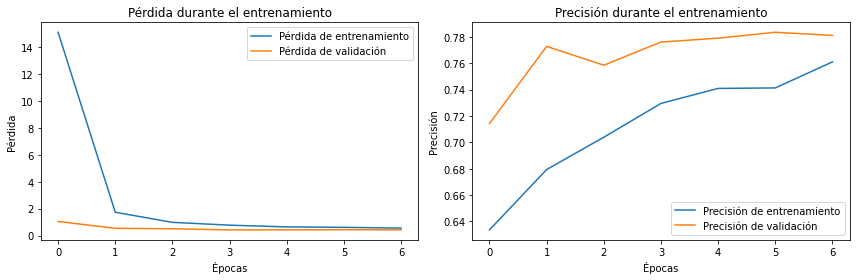

In [9]:
# Llamar a la función para trazar el historial
plot_history(conv2D_modelo)

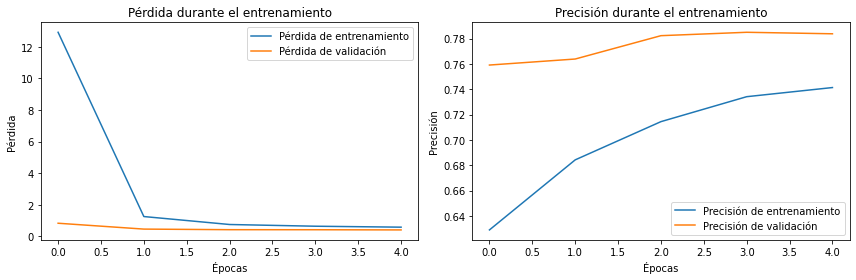

In [23]:
# Llamar a la función para trazar el historial
plot_history(conv2D_modelo)